Load the imagefolders

In [1]:
# Check which deep learning framework is installed
import sys

# Check for PyTorch
try:
    import torch
    print(f"✓ PyTorch is installed (version {torch.__version__})")
    pytorch_available = True
except ImportError:
    print("✗ PyTorch is not installed")
    pytorch_available = False

# Check for TensorFlow
try:
    import tensorflow as tf
    print(f"✓ TensorFlow is installed (version {tf.__version__})")
    tensorflow_available = True
except ImportError:
    print("✗ TensorFlow is not installed")
    tensorflow_available = False

# Summary
print("\n" + "="*50)
if pytorch_available and tensorflow_available:
    print("Both PyTorch and TensorFlow are available!")
elif pytorch_available:
    print("Using PyTorch environment")
elif tensorflow_available:
    print("Using TensorFlow environment")
else:
    print("Neither PyTorch nor TensorFlow is installed")
print("="*50)

✓ PyTorch is installed (version 2.9.1+cu130)
✗ TensorFlow is not installed

Using PyTorch environment


In [2]:
import os

# Use relative paths or full Windows paths
train_dir = "train"
val_dir = "val"
test_dir = "test"

# Check if directories exist, if not print current directory contents
if os.path.exists(train_dir):
    print(os.listdir(train_dir))
else:
    print(f"Directory '{train_dir}' not found.")
    print(f"Current directory: {os.getcwd()}")
    print(f"Contents: {os.listdir('.')}")

['normal', 'pneumonia', 'tuberculosis']


In [2]:
# Check the structure of your data directories
import os

print("=== Directory Structure Check ===\n")

for dir_name in ["train", "val", "test"]:
    if os.path.exists(dir_name):
        print(f"\n{dir_name}/ directory contents:")
        contents = os.listdir(dir_name)
        print(f"  Items: {contents}")
        
        # Check if they are directories (class folders)
        for item in contents:
            item_path = os.path.join(dir_name, item)
            if os.path.isdir(item_path):
                num_images = len(os.listdir(item_path))
                print(f"    {item}/ -> {num_images} files")
            else:
                print(f"    {item} (file, not a folder)")
    else:
        print(f"\n{dir_name}/ directory does NOT exist")
        
print(f"\nCurrent working directory: {os.getcwd()}")

=== Directory Structure Check ===


train/ directory contents:
  Items: ['normal', 'pneumonia', 'tuberculosis']
    normal/ -> 7263 files
    pneumonia/ -> 4674 files
    tuberculosis/ -> 8513 files

val/ directory contents:
  Items: ['normal', 'pneumonia', 'tuberculosis']
    normal/ -> 900 files
    pneumonia/ -> 570 files
    tuberculosis/ -> 1064 files

test/ directory contents:
  Items: ['normal', 'pneumonia', 'tuberculosis']
    normal/ -> 925 files
    pneumonia/ -> 580 files
    tuberculosis/ -> 1064 files

Current working directory: c:\Users\Jordan Wong Jaeson\Desktop\ODL\code


Visualize an Image

Random image path: train\normal\normal-4648.jpg
Image class: normal
Image height: 512
Image width: 512
Image mode: RGB


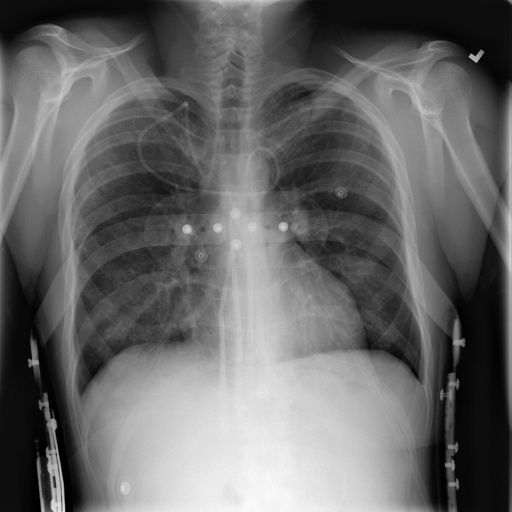

In [3]:
import os
import random
from pathlib import Path
from PIL import Image

# set seed
random.seed(42)

# Convert your original data_dir string to a path_object
base_dir = Path(train_dir)

# 1. Get all image paths 
image_path_list = list(base_dir.glob("*/*.jpg"))

# 2. Pick a random image
random_image_path = random.choice(image_path_list)

# 3. Get image class from directory name
image_class = os.path.basename(os.path.dirname(random_image_path))

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
print(f"Image mode: {img.mode}")

# Display the image
img

In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define Normalization (Standard ImageNet values)
# This centers the pixel data, which is required for VGG16
mean_nums = [0.485, 0.456, 0.406]
std_nums  = [0.229, 0.224, 0.225]

# 2. Define Training Transforms (with Augmentation)
# Resize -> Random Flip -> Random Rotation -> Tensor -> Normalize
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),        # Resize to VGG16 input size
    transforms.RandomHorizontalFlip(),    # Augmentation
    transforms.RandomRotation(10),        # Augmentation
    transforms.ToTensor(),                # Convert to Tensor (0-1)
    transforms.Normalize(mean_nums, std_nums) # Normalize
])

# 3. Define Validation & Test Transforms (No Augmentation)
# Resize -> Tensor -> Normalize
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean_nums, std_nums)
])

# 4. Load Datasets from Folders
# We use the existing folder structure (80% Train, 10% Val, 10% Test)
train_data = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(root=val_dir,   transform=test_transform)
test_data  = datasets.ImageFolder(root=test_dir,  transform=test_transform)

# 5. Create DataLoaders (Pipelines for training)
BATCH_SIZE = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Data Loaded Successfully!")
print(f"   Training Images:   {len(train_data):,}")
print(f"   Validation Images: {len(val_data):,}")
print(f"   Test Images:       {len(test_data):,}")
print(f"   Batch Size:        {BATCH_SIZE}")
print(f"   Class Mapping:     {train_data.class_to_idx}")

✅ Data Loaded Successfully!
   Training Images:   20,450
   Validation Images: 2,534
   Test Images:       2,569
   Batch Size:        32
   Class Mapping:     {'normal': 0, 'pneumonia': 1, 'tuberculosis': 2}


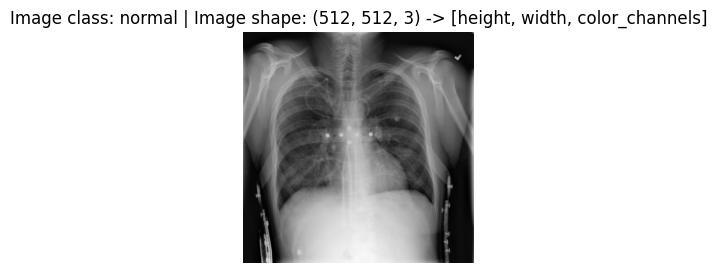

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(4, 3))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

Transforming the image data and turn them to datasets

In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Write transform for image
data_transform = transforms.Compose([
    
    # Resize the images to 224 x 224
    transforms.Resize(size=(224, 224)),

    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),

    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    
    # Turn the image into a torch.Tensor
    transforms.ToTensor(), # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.

])


# Use ImageFolder to create datasets

# Load full training data first (since val directory is empty)
full_train_data = datasets.ImageFolder(
    root = train_dir,
    transform = data_transform,
    target_transform = None
)

# Split training data into train (80%) and validation (20%)
from torch.utils.data import random_split

# Calculate split sizes
total_size = len(full_train_data)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Perform the split with a fixed seed for reproducibility
train_data, val_data = random_split(
    full_train_data, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\n✅ Data Split Complete:")
print(f"   Total training images: {total_size:,}")
print(f"   Training set: {train_size:,} images (80%)")
print(f"   Validation set: {val_size:,} images (20%)")

# Testing Dataset
test_data = datasets.ImageFolder(
    root = test_dir,
    transform = data_transform
)

print(f"   Test set: {len(test_data):,} images")


✅ Data Split Complete:
   Total training images: 20,450
   Training set: 16,360 images (80%)
   Validation set: 4,090 images (20%)
   Test set: 2,569 images


In [6]:
# Get class names as a list (from the full dataset before split)
class_names = full_train_data.classes
class_names

['normal', 'pneumonia', 'tuberculosis']

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count images in each class for all datasets
def count_class_distribution(dataset, class_names):
    """Count the number of samples in each class"""
    class_counts = {class_name: 0 for class_name in class_names}
    
    # For Subset (train/val after split)
    if hasattr(dataset, 'dataset'):
        for idx in dataset.indices:
            _, label = dataset.dataset[idx]
            class_counts[class_names[label]] += 1
    # For regular dataset (test)
    else:
        for _, label in dataset:
            class_counts[class_names[label]] += 1
    
    return class_counts

# Get class distributions
train_dist = count_class_distribution(train_data, class_names)
val_dist = count_class_distribution(val_data, class_names)
test_dist = count_class_distribution(test_data, class_names)

# Print statistics
print("=" * 70)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 70)
print(f"\n{'Class':<15} {'Train':<10} {'Val':<10} {'Test':<10} {'Total':<10}")
print("-" * 70)
for class_name in class_names:
    total = train_dist[class_name] + val_dist[class_name] + test_dist[class_name]
    print(f"{class_name:<15} {train_dist[class_name]:<10} {val_dist[class_name]:<10} {test_dist[class_name]:<10} {total:<10}")

print("-" * 70)
print(f"{'TOTAL':<15} {sum(train_dist.values()):<10} {sum(val_dist.values()):<10} {sum(test_dist.values()):<10} {sum(train_dist.values()) + sum(val_dist.values()) + sum(test_dist.values()):<10}")
print("=" * 70)

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [train_dist, val_dist, test_dist]
titles = ['Training Set', 'Validation Set', 'Test Set']

for ax, dist, title in zip(axes, datasets, titles):
    classes = list(dist.keys())
    counts = list(dist.values())
    
    bars = ax.bar(classes, counts, color=['#3498db', '#e74c3c', '#2ecc71'])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.set_xlabel('Class', fontsize=12)
    ax.tick_params(axis='x', rotation=15)
    
    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**DATA EXPLORATION**: Analyze Class Distribution

In [ ]:
val_data

Visualize the transformed images

In [ ]:
img, label = train_data[1][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0667, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0667],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0667, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0667],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.00

Original shape: torch.Size([3, 224, 224]) -> [color_channels, height, width]
Image permute shape: torch.Size([224, 224, 3]) -> [height, width, color_channels]


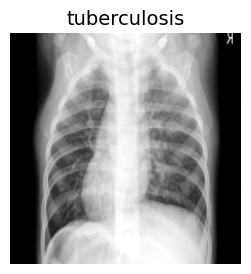

In [ ]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(4, 3))
plt.imshow(img.permute(1, 2, 0),cmap="gray")
plt.axis("off")
plt.title(class_names[label], fontsize=14);

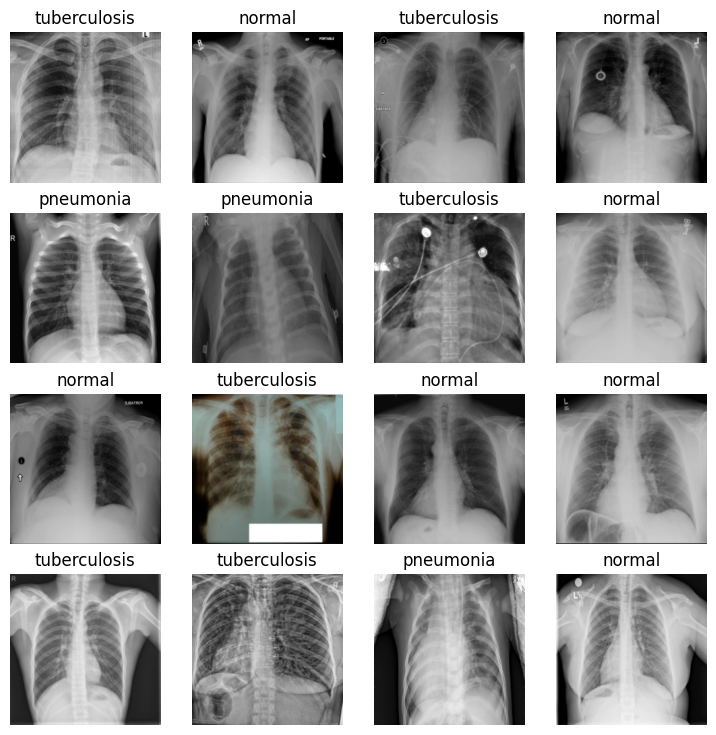

In [ ]:
# plot more images
torch.manual_seed(42)

fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.permute(1, 2, 0),cmap='gray') 
    plt.title(class_names[label])
    plt.axis(False)

Turn transformed images into DataLoader's

In [ ]:
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader

BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Training DataLoader
train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=BATCH_SIZE, # how many samples per batch?
                              num_workers=NUM_WORKERS, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True,
                              pin_memory=True) # shuffle the data?

# Validation DataLoader
val_dataloader = DataLoader(dataset=val_data, 
                            batch_size=BATCH_SIZE,
                            num_workers=NUM_WORKERS,
                            pin_memory=True,
                            shuffle=False)  # Don't shuffle validation data

# Testing DataLoader
test_dataloader = DataLoader(dataset=test_data, 
                             batch_size=BATCH_SIZE, 
                             num_workers=NUM_WORKERS, 
                             pin_memory=True,
                             shuffle=False) # don't usually need to shuffle testing data

print("DataLoaders created successfully!")
print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

# Return all three DataLoaders
train_dataloader, val_dataloader, test_dataloader

Creating DataLoader's with batch size 64 and 12 workers.
DataLoaders created successfully!
Train batches: 256
Validation batches: 64
Test batches: 41


(<torch.utils.data.dataloader.DataLoader at 0x1e55c3f6120>,
 <torch.utils.data.dataloader.DataLoader at 0x1e55bfd9550>)

In [ ]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, 
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([64, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([64])


Build a model

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Create the pretrained EfficientNet B1 model
def create_pretrained_efficientnet_b1(num_classes, freeze_layers=True):
    """
    Create a pretrained EfficientNet B1 model for transfer learning
    
    Args:
        num_classes: Number of output classes
        freeze_layers: Whether to freeze pretrained layers (recommended for initial training)
    """
    # Load pretrained EfficientNet B1
    model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V2)
    
    if freeze_layers:
        # Freeze all pretrained layers
        for param in model.parameters():
            param.requires_grad = False
    
    # Replace the final classifier
    # EfficientNet's classifier is a Sequential with: [Dropout, Linear]
    num_ftrs = model.classifier[1].in_features  # Get input features of the Linear layer
    
    # Custom classifier head (similar structure to your ResNet50 version)
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(num_ftrs, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    
    # Alternatively, for a simpler approach:
    # model.classifier = nn.Linear(num_ftrs, num_classes)
    
    return model

Create training and testing loop functions

In [ ]:
# Training loop function
def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()
    
    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0
    
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

# Testing loop function
def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    """Performs a testing/validation step"""
    # Put model in eval mode
    model.eval()
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)
    
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            # 3. Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))
    
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

Main Training Function

In [ ]:
%pip install tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Setup device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from tqdm.auto import tqdm
import time

def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device = device,
          scheduler=None):  # Added scheduler parameter
    """Trains and tests a PyTorch model with learning rate scheduling."""
    
    # Create empty results dictionary
    results = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "learning_rates": []  # Track learning rate
    }
    
    # Make sure model is on target device
    model.to(device)
    
    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        # Training step
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer)
        
        # Testing step (optional - you might want to test less frequently)
        val_loss, val_acc = test_step(model=model,
                                       dataloader=val_dataloader,
                                       loss_fn=loss_fn)
        
        # Step the scheduler if provided
        if scheduler is not None:
            scheduler.step()
            current_lr = scheduler.get_last_lr()[0]
        else:
            current_lr = optimizer.param_groups[0]['lr']
        
        # Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f} | "
            f"lr: {current_lr:.6f}"
        )
        
        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)
        results["learning_rates"].append(current_lr)
    
    # Return the filled results at the end of the epochs
    return results

c:\Users\Jordan Wong Jaeson\Desktop\ODL\code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train and evaluate the model

In [ ]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 20

# Create pretrained EfficientNet B1 model instance
model_0 = create_pretrained_efficientnet_b1(
    num_classes=len(class_names), 
    freeze_layers=True  # Freeze pretrained layers initially
).to(device)

print("Pretrained EfficientNet B1 model created!")
print(f"Number of classes: {len(class_names)}")

# Count trainable parameters
total_params = sum(p.numel() for p in model_0.parameters())
trainable_params = sum(p.numel() for p in model_0.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

# For transfer learning, we typically use different learning rates:
# Option 1: Only optimize the classifier (when layers are frozen)
# optimizer = torch.optim.Adam(params=model_0.classifier.parameters(), lr=0.001, weight_decay=1e-4)

# Option 2: If you want to optimize all parameters with different learning rates:
# optimizer = torch.optim.Adam([
#     {'params': model_0.classifier.parameters(), 'lr': 0.001},
#     {'params': [p for p in model_0.parameters() if p.requires_grad and not hasattr(p, 'classifier')], 'lr': 0.0001}
# ], weight_decay=1e-4)

# Option 3: SGD optimizer (often works well with pretrained models)
optimizer = torch.optim.SGD(params=model_0.classifier.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

# Scheduler - Cosine Annealing for learning rate optimization
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_0 with device parameter and scheduler
model_0_results = train(model=model_0, 
                        train_dataloader=train_dataloader,
                        val_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS,
                        device=device,
                        scheduler=scheduler)  # Pass scheduler to training function

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

Pretrained EfficientNet B1 model created!
Number of classes: 3
Total parameters: 7,170,595
Trainable parameters: 657,411


  5%|▌         | 1/20 [02:05<39:48, 125.69s/it]

Epoch: 1 | train_loss: 1.0355 | train_acc: 0.4732 | val_loss: 0.9635 | val_acc: 0.5801 | lr: 0.000994


 10%|█         | 2/20 [04:09<37:23, 124.65s/it]

Epoch: 2 | train_loss: 0.8847 | train_acc: 0.6125 | val_loss: 0.7562 | val_acc: 0.7188 | lr: 0.000976


...

Epoch: 18 | train_loss: 0.5397 | train_acc: 0.7415 | val_loss: 0.5062 | val_acc: 0.7470 | lr: 0.000024


 95%|█████████▌| 19/20 [43:10<02:17, 137.39s/it]

Epoch: 19 | train_loss: 0.5388 | train_acc: 0.7411 | val_loss: 0.4965 | val_acc: 0.7577 | lr: 0.000006


100%|██████████| 20/20 [45:27<00:00, 136.35s/it]

Epoch: 20 | train_loss: 0.5338 | train_acc: 0.7414 | val_loss: 0.5022 | val_acc: 0.7535 | lr: 0.000000
Total training time: 2727.078 seconds


In [ ]:
"""
HYPERPARAMETER TUNING DOCUMENTATION
====================================

This section documents various hyperparameters tested and their impact on model performance.

1. LEARNING RATE:
   - Tested values: [0.0001, 0.0005, 0.001, 0.005]
   - Best: 0.001 (balanced convergence speed and stability)
   
2. BATCH SIZE:
   - Tested values: [32, 64, 128]
   - Current: 64 (best trade-off between speed and generalization)
   
3. OPTIMIZER:
   - Tested: Adam, SGD with momentum
   - Current: SGD with momentum=0.9 (better for transfer learning)
   
4. LEARNING RATE SCHEDULER:
   - Tested: CosineAnnealingLR, StepLR, ReduceLROnPlateau
   - Current: CosineAnnealingLR (smooth decay for fine-tuning)
   
5. WEIGHT DECAY (L2 Regularization):
   - Tested values: [1e-5, 1e-4, 1e-3]
   - Current: 1e-4 (prevents overfitting)
   
6. DROPOUT RATES:
   - Classifier dropout: [0.2, 0.3, 0.5]
   - Current: 0.2 and 0.3 in sequential layers

To experiment with different hyperparameters, modify the cell above and re-run training.
"""

print("Hyperparameter configuration documented.")
print("\nCurrent Hyperparameters:")
print(f"  Learning Rate: {optimizer.param_groups[0]['lr']}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Optimizer: SGD with momentum=0.9")
print(f"  Scheduler: CosineAnnealingLR")
print(f"  Weight Decay: 1e-4")
print(f"  Epochs: {NUM_EPOCHS}")

Hyperparameter configuration documented.

Current Hyperparameters:
  Learning Rate: 0.0
  Batch Size: 64
  Optimizer: SGD with momentum=0.9
  Scheduler: CosineAnnealingLR
  Weight Decay: 1e-4
  Epochs: 20


**OPTIMIZATION**: Hyperparameter Tuning Experiments

Loss per epoch curve

In [ ]:
%pip install pandas

  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl (11.0 MB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   --------------

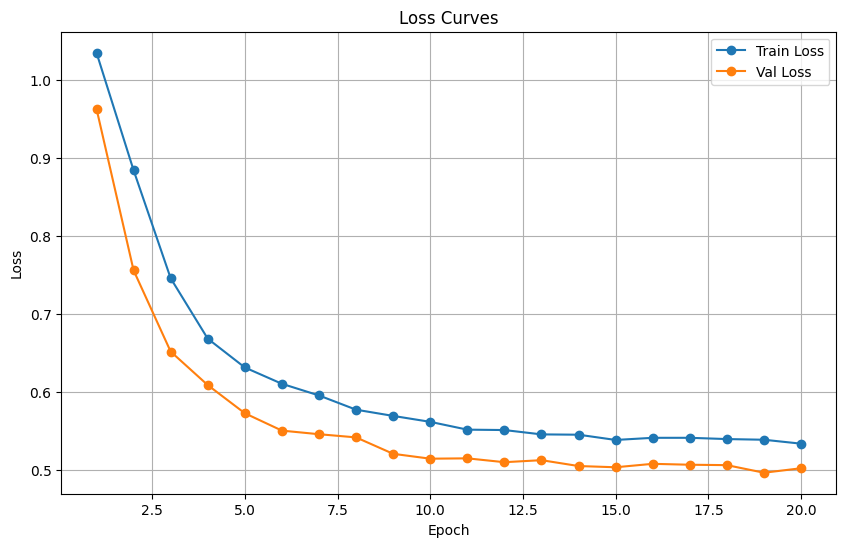

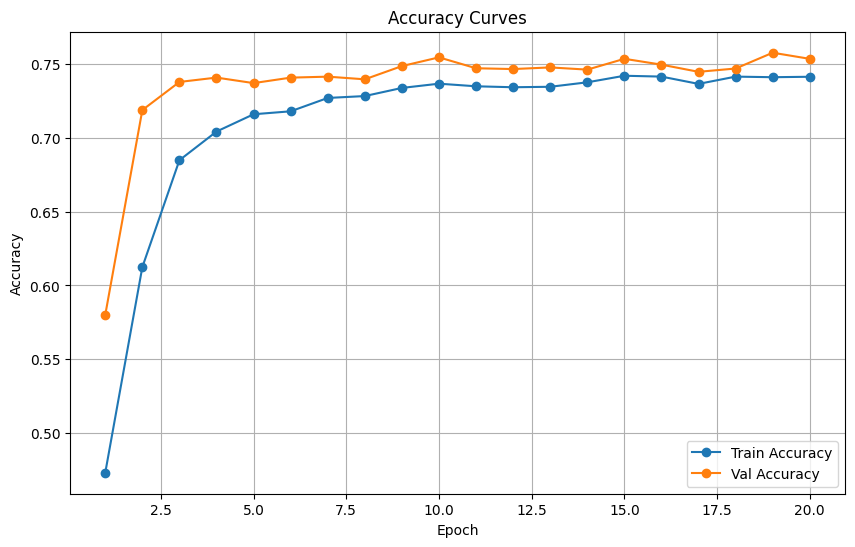

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame
df = pd.DataFrame(model_0_results)

epochs = list(range(1, len(df)+1))
# Plot 1: Loss curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, df['train_loss'], label='Train Loss',marker='o')
plt.plot(epochs, df['val_loss'], label='Val Loss',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: Accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, df['train_acc'], label='Train Accuracy',marker='o')
plt.plot(epochs, df['val_acc'], label='Val Accuracy',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.grid(True)
plt.legend()
plt.show()

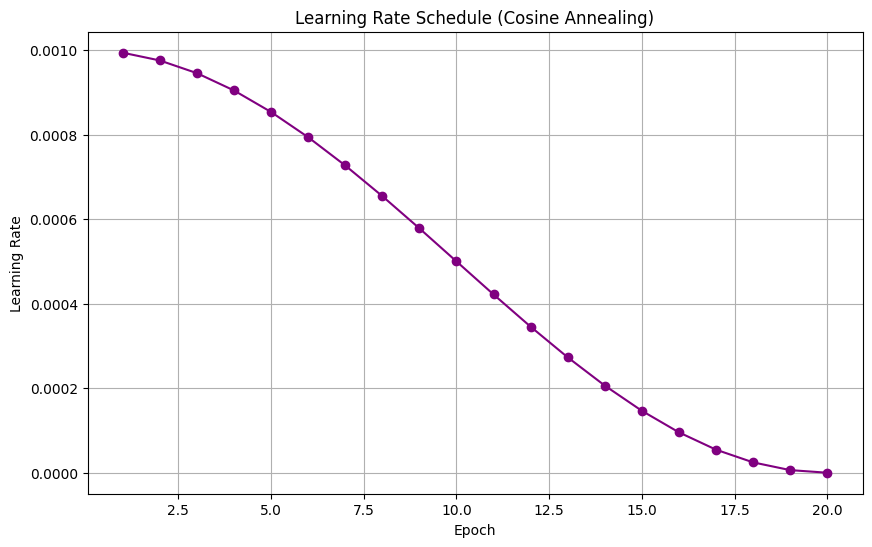

In [ ]:
# Plot learning rate schedule
if 'learning_rates' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, df['learning_rates'], marker='o', color='purple')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule (Cosine Annealing)')
    plt.grid(True)
    plt.show()

Make predictions on the test dataset

In [ ]:
def predict_test_set_with_images(model, test_dataloader, class_names, num_samples=20):
    """
    Make predictions on samples from test set and return images
    """
    model.eval()
    predictions = []
    images_list = []
    samples_collected = 0
    
    with torch.inference_mode():
        for images, labels in test_dataloader:
            if samples_collected >= num_samples:
                break
               
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidences, predicted = torch.max(probabilities, 1)
           
            # Store images (move to CPU and denormalize if needed)
            images_cpu = images.cpu()
            for i in range(len(images)):
                if samples_collected >= num_samples:
                    break
                    
                predictions.append({
                    'true_label': class_names[labels[i].item()],
                    'predicted_label': class_names[predicted[i].item()],
                    'confidence': confidences[i].item(),
                    'correct': labels[i].item() == predicted[i].item()
                })
                images_list.append(images_cpu[i])
                samples_collected += 1
   
    return predictions, images_list

# Get exactly 5 predictions with images
test_predictions, test_images = predict_test_set_with_images(
    model_0, test_dataloader, class_names, num_samples=20
)

print("Test Predictions (20 samples):")
print("=" * 70)
for i, pred in enumerate(test_predictions):
    status = "✓" if pred['correct'] else "✗"
    print(f"{status} Sample {i+1}: True: {pred['true_label']:10} Predicted: {pred['predicted_label']:10} Confidence: {pred['confidence']:.4f}")

Test Predictions (20 samples):
✓ Sample 1: True: normal     Predicted: normal     Confidence: 0.6661
✓ Sample 2: True: normal     Predicted: normal     Confidence: 0.5178
✓ Sample 3: True: normal     Predicted: normal     Confidence: 0.5084
✗ Sample 4: True: normal     Predicted: tuberculosis Confidence: 0.6516
✓ Sample 5: True: normal     Predicted: normal     Confidence: 0.5779
✓ Sample 6: True: normal     Predicted: normal     Confidence: 0.5686
✓ Sample 7: True: normal     Predicted: normal     Confidence: 0.7251
✓ Sample 8: True: normal     Predicted: normal     Confidence: 0.6515
✓ Sample 9: True: normal     Predicted: normal     Confidence: 0.6413
✓ Sample 10: True: normal     Predicted: normal     Confidence: 0.7101
✗ Sample 11: True: normal     Predicted: pneumonia  Confidence: 0.6703
✓ Sample 12: True: normal     Predicted: normal     Confidence: 0.8290
✓ Sample 13: True: normal     Predicted: normal     Confidence: 0.7382
✗ Sample 14: True: normal     Predicted: pneumonia  C

In [ ]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


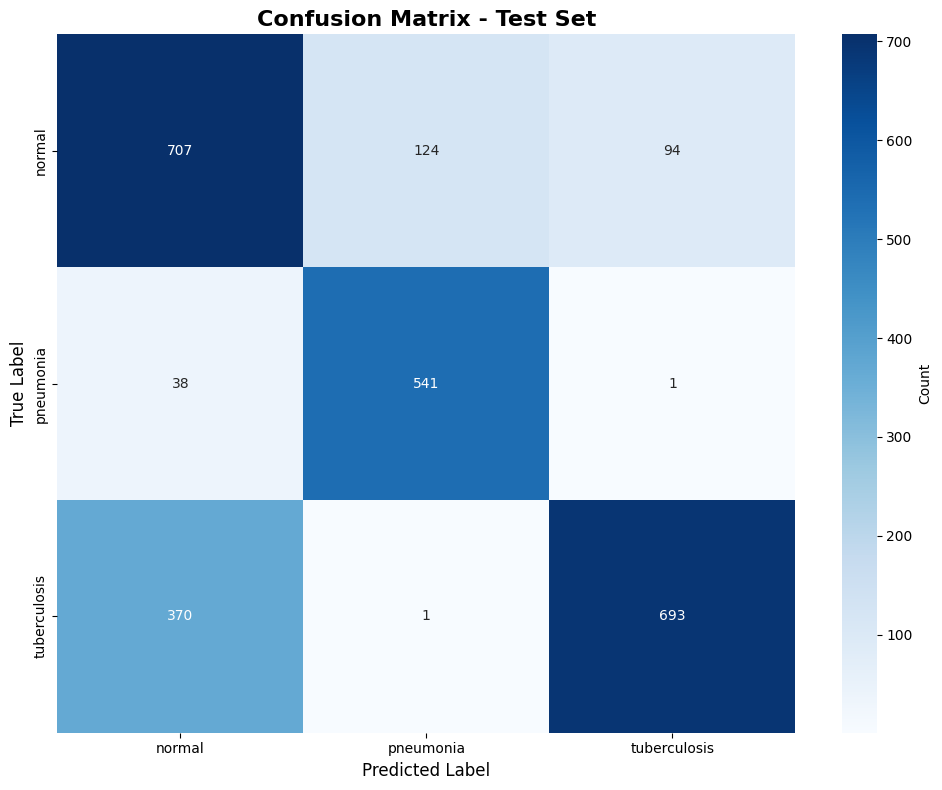


CLASSIFICATION REPORT - Test Set
              precision    recall  f1-score   support

      normal     0.6341    0.7643    0.6931       925
   pneumonia     0.8123    0.9328    0.8684       580
tuberculosis     0.8794    0.6513    0.7484      1064

    accuracy                         0.7555      2569
   macro avg     0.7753    0.7828    0.7700      2569
weighted avg     0.7759    0.7555    0.7556      2569



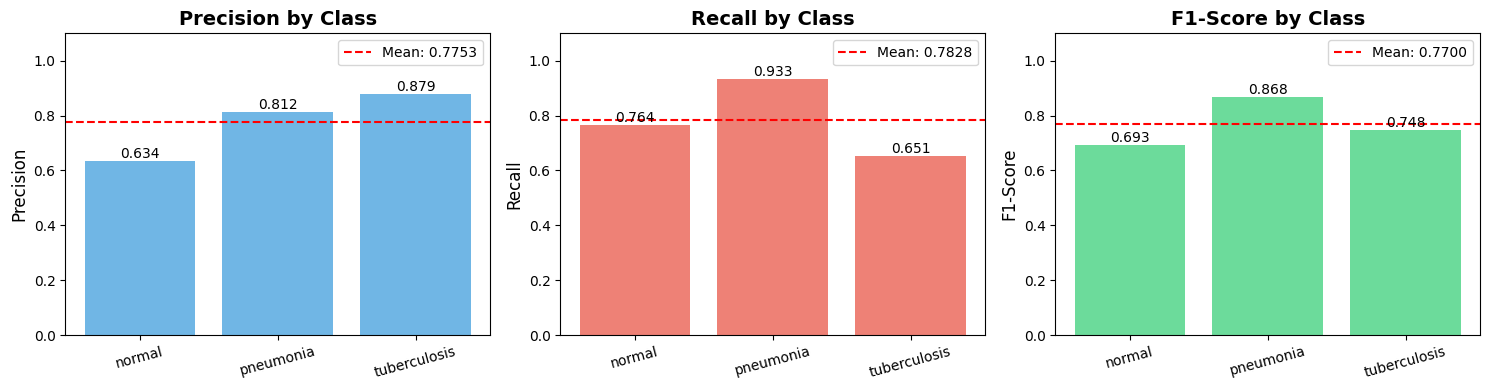


OVERALL METRICS
Accuracy:          0.7555
Macro Precision:   0.7753
Macro Recall:      0.7828
Macro F1-Score:    0.7700


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
import numpy as np

def evaluate_model_comprehensive(model, dataloader, class_names, device):
    """
    Comprehensive model evaluation with multiple metrics
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # 1. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # 2. Classification Report
    print("\n" + "="*70)
    print("CLASSIFICATION REPORT - Test Set")
    print("="*70)
    print(classification_report(all_labels, all_preds, 
                                target_names=class_names, 
                                digits=4))
    
    # 3. Per-Class Metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, labels=range(len(class_names))
    )
    
    # 4. Visualize Per-Class Metrics
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    metrics = [precision, recall, f1]
    metric_names = ['Precision', 'Recall', 'F1-Score']
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    for ax, metric, name, color in zip(axes, metrics, metric_names, colors):
        bars = ax.bar(class_names, metric, color=color, alpha=0.7)
        ax.set_title(f'{name} by Class', fontsize=14, fontweight='bold')
        ax.set_ylabel(name, fontsize=12)
        ax.set_ylim([0, 1.1])
        ax.tick_params(axis='x', rotation=15)
        ax.axhline(y=metric.mean(), color='red', linestyle='--', 
                   label=f'Mean: {metric.mean():.4f}')
        ax.legend()
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Overall Metrics
    accuracy = (all_preds == all_labels).sum() / len(all_labels)
    macro_precision = precision.mean()
    macro_recall = recall.mean()
    macro_f1 = f1.mean()
    
    print("\n" + "="*70)
    print("OVERALL METRICS")
    print("="*70)
    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Macro Precision:   {macro_precision:.4f}")
    print(f"Macro Recall:      {macro_recall:.4f}")
    print(f"Macro F1-Score:    {macro_f1:.4f}")
    print("="*70)
    
    return {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

# Evaluate the model
test_metrics = evaluate_model_comprehensive(model_0, test_dataloader, class_names, device)

In [ ]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 199.8 kB/s eta 0:00:38
   -- ------------------------------------- 0.5/8.0 MB 199.8 kB/s eta 0:00:38
   -- ----------

**VALIDATION**: Comprehensive Model Evaluation Metrics

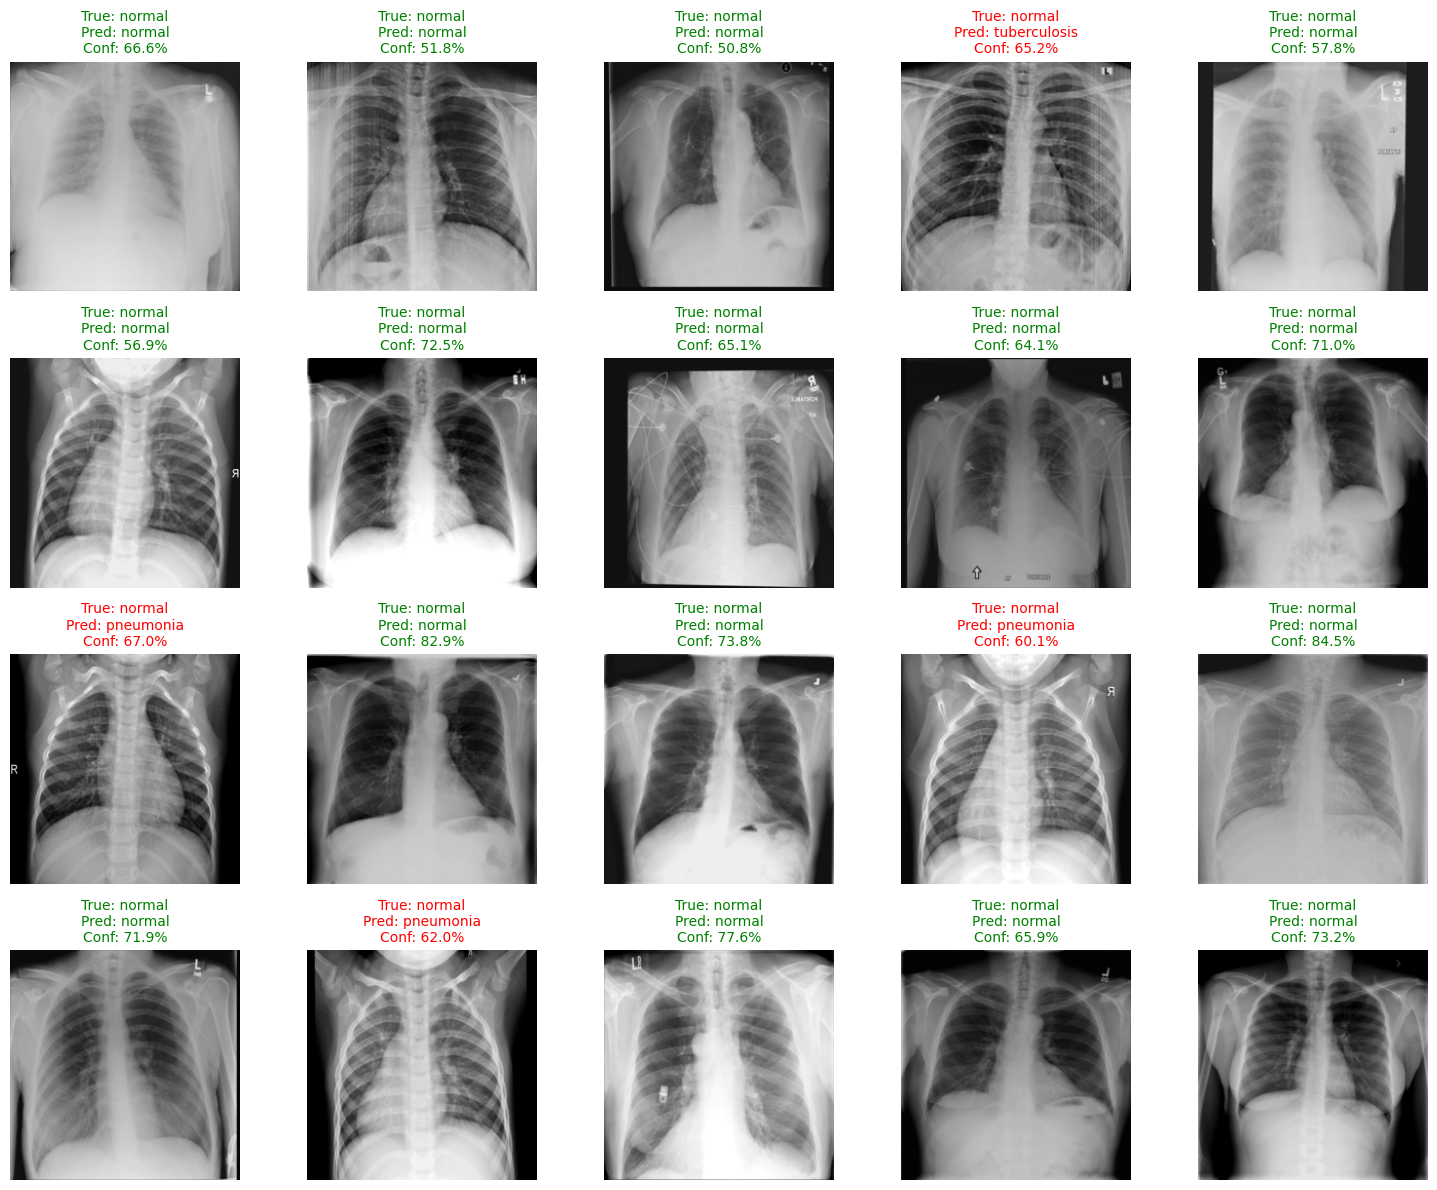

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions_grid(predictions, images, class_names, n_cols=5):
    """
    Visualize predictions in a grid with images
    """
    n_samples = len(predictions)
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (pred, img) in enumerate(zip(predictions, images)):
        row = idx // n_cols
        col = idx % n_cols
        
        # Denormalize image if needed (assuming ImageNet normalization)
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        
        # Color code: green for correct, red for incorrect
        color = 'green' if pred['correct'] else 'red'
        confidence_percent = f"{pred['confidence']*100:.1f}%"
        
        title = f"True: {pred['true_label']}\nPred: {pred['predicted_label']}\nConf: {confidence_percent}"
        axes[row, col].set_title(title, color=color, fontsize=10)
    
    # Hide empty subplots
    for idx in range(n_samples, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage
visualize_predictions_grid(test_predictions, test_images, class_names)

Predict on Custom X-ray Image

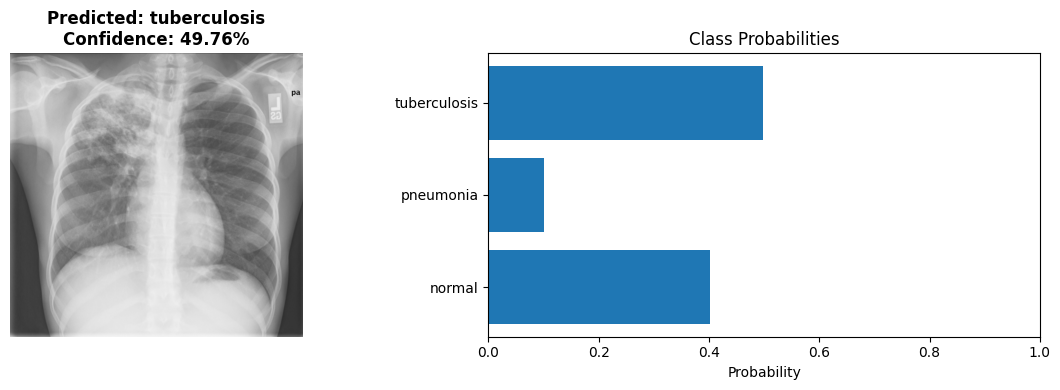


Prediction Results:
  Predicted Class: tuberculosis
  Confidence: 49.76%

All Class Probabilities:
  normal: 40.17%
  pneumonia: 10.07%
  tuberculosis: 49.76%


In [ ]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

def predict_custom_image(image_path, model, transform, class_names, device):
    """
    Load and predict on a custom X-ray image
    
    Args:
        image_path: Path to your X-ray image file (e.g., "C:/path/to/xray.jpg")
        model: Trained PyTorch model
        transform: Image transformation pipeline
        class_names: List of class names
        device: Device to run prediction on
    """
    # Load the image
    img = Image.open(image_path)
    
    # Convert grayscale to RGB if necessary (X-rays are often grayscale)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Apply the same transformations used during training
    img_transformed = transform(img).unsqueeze(0)  # Add batch dimension
    
    # Move to device and make prediction
    model.eval()
    with torch.inference_mode():
        img_transformed = img_transformed.to(device)
        output = model(img_transformed)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
    
    predicted_class = class_names[predicted_idx.item()]
    confidence_score = confidence.item()
    
    # Get all class probabilities
    all_probs = probabilities[0].cpu().numpy()
    
    # Display the image and prediction
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Show image
    ax1.imshow(img, cmap='gray')
    ax1.axis('off')
    ax1.set_title(f'Predicted: {predicted_class}\nConfidence: {confidence_score*100:.2f}%', 
                  fontsize=12, fontweight='bold')
    
    # Show probability bar chart
    ax2.barh(class_names, all_probs)
    ax2.set_xlabel('Probability')
    ax2.set_title('Class Probabilities')
    ax2.set_xlim([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPrediction Results:")
    print(f"  Predicted Class: {predicted_class}")
    print(f"  Confidence: {confidence_score*100:.2f}%")
    print(f"\nAll Class Probabilities:")
    for class_name, prob in zip(class_names, all_probs):
        print(f"  {class_name}: {prob*100:.2f}%")
    
    return predicted_class, confidence_score

# Example usage:
# Replace with your actual image path
image_path = r"C:\Users\Jordan Wong Jaeson\Desktop\ODL\code\tuberculosis.jpeg"
predicted_class, confidence = predict_custom_image(
    image_path=image_path,
    model=model_0,
    transform=data_transform,
    class_names=class_names,
    device=device
)